In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [3]:
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2509.51536,1.0,1249.0,2505.0,3764.0,5000.0,1448.68904
age,25000.0,NaN,NaN,NaN,44.76832,1.0,33.0,45.0,57.0,90.0,17.784232
gender,25000,2,F,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Hyderabad,4370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,MediCareX,6532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.5026,0.0,0.0,1.0,1.0,1.0,0.500003
registration_date,25000,NaN,NaN,NaN,2025-07-18 16:17:11.040000,2025-01-20 00:00:00,2025-04-16 00:00:00,2025-07-19 00:00:00,2025-10-19 00:00:00,2026-01-20 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-07-21 15:25:51.744000256,2025-01-20 00:00:00,2025-04-21 00:00:00,2025-07-21 00:00:00,2025-10-21 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,4228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [7]:
df[["approved_amount", "payment_days", "length_of_stay_hours"]].isnull().sum()

approved_amount         1318
payment_days             790
length_of_stay_hours       0
dtype: int64

In [8]:
df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
].shape

(817, 20)

In [9]:
df[df["payment_days"].isna()]["claim_status"].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

In [10]:
(df["length_of_stay_hours"]<0).sum()

np.int64(0)

In [11]:
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

======Visit Type=================
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

=======City=======================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


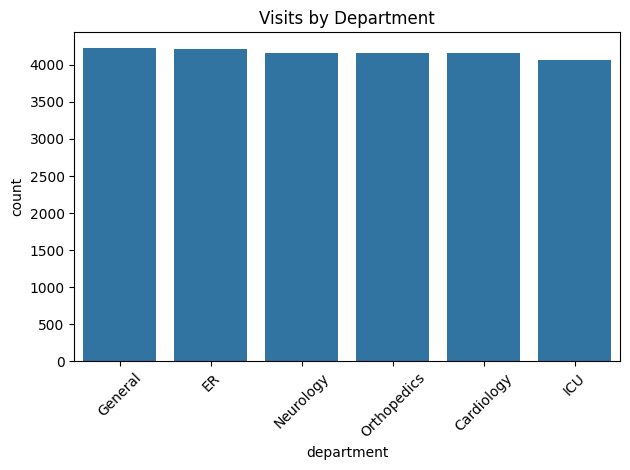

In [12]:
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

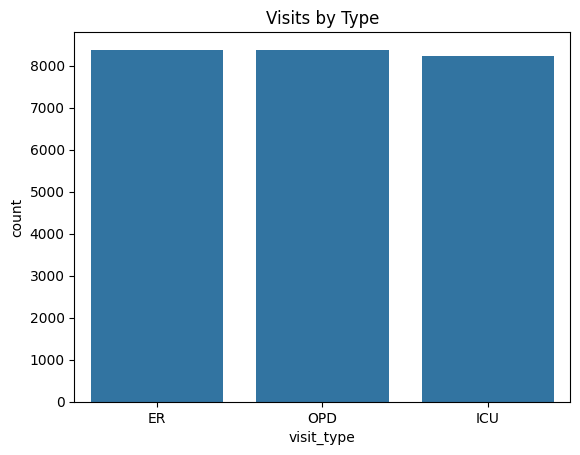

In [13]:
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.show()

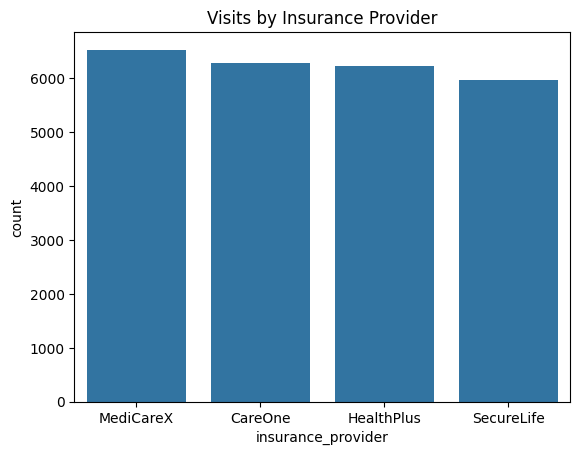

In [14]:
sns.countplot(data=df, x="insurance_provider", order=df["insurance_provider"].value_counts().index)
plt.title("Visits by Insurance Provider")
plt.show()

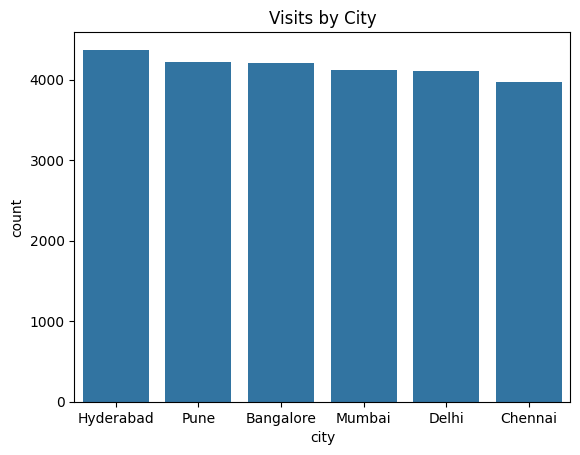

In [15]:
sns.countplot(data=df, x="city", order=df["city"].value_counts().index)
plt.title("Visits by City")
plt.show()

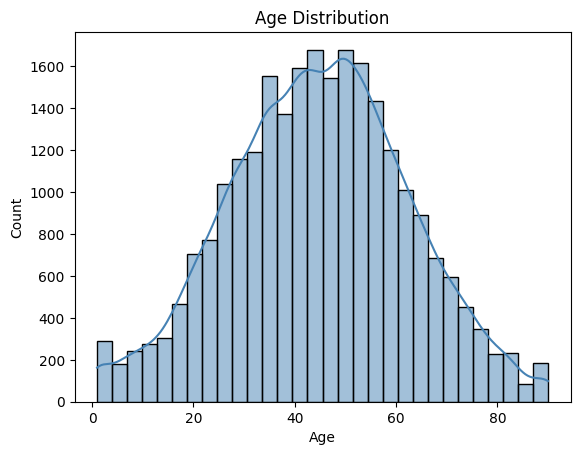

count    25000.00
mean        44.77
std         17.78
min          1.00
25%         33.00
50%         45.00
75%         57.00
max         90.00
Name: age, dtype: float64


In [16]:
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe().round(2))

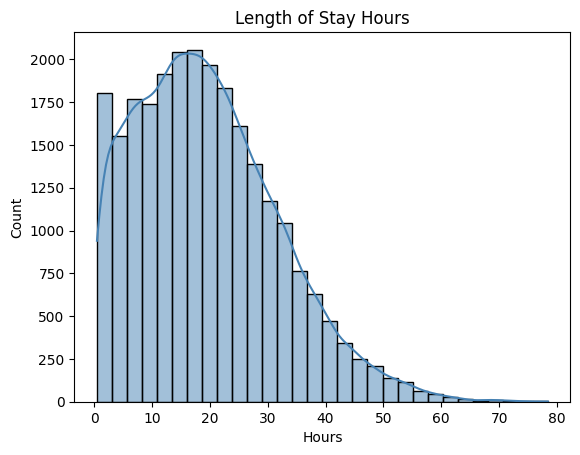

count    25000.00
mean        19.55
std         12.31
min          0.50
25%          9.96
50%         18.20
75%         27.31
max         78.42
Name: length_of_stay_hours, dtype: float64


In [17]:
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [18]:
IQR = 27.31 - 9.96 
print(IQR)

17.349999999999998


In [19]:
upper_fence = 27.31 + (1.5*17.35)
print(upper_fence)

53.335
